In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')
import importlib
import pandas as pd


## MultiLayerPerceptron class import

In [2]:

module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'hERG_mlp.csv')
df_existing = pd.read_csv(csv_filename)
df_existing = df_existing.sort_values(by="mcc", ascending=False)
display(df_existing)

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
735,736,0.432115,0.773270,0.727099,133.261373,0.894616,187,0.006551,0.049417,558,512,AdamW,0.00010,"[4096, 1024, 256, 64, 8]"
912,913,0.431943,0.771284,0.726460,129.902783,0.313820,77,0.000031,0.000002,1911,64,AdamW,0.00010,[200]
879,880,0.430777,0.773904,0.726779,56.623326,0.642643,20,0.000063,0.000281,1354,64,AdamW,0.00010,"[1000, 50]"
969,970,0.428984,0.769519,0.724864,33.982390,0.102211,55,0.002442,0.000034,1963,128,AdamW,0.00010,[200]
864,865,0.428984,0.769519,0.724864,116.365534,0.522548,130,0.000256,0.100000,1749,128,AdamW,0.00010,[200]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,684,-0.041517,0.513522,0.477498,46.051559,0.214260,115,0.000910,0.039069,1250,1024,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
850,851,-0.041517,0.513522,0.477498,21.653428,0.687862,11,0.000031,0.000001,245,64,RMSprop,1.00000,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
557,558,-0.065613,0.444229,0.451325,31.355584,0.868965,26,0.003728,0.012068,1756,256,RMSprop,0.00001,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
278,279,-0.068673,0.691224,0.545164,72.282222,0.546922,197,0.000047,0.000003,1214,1024,RMSprop,1.00000,[200]


In [4]:
best_results = df_existing.iloc[:3, 5:]
best_results_mlp_dicts = []
for i,j in best_results.iterrows():
    best_results_mlp_dicts.append(dict(j))

In [5]:
best_results_mlp_dicts

[{'dropout_frac': 0.8946158157218873,
  'patience': 187,
  'tol': 0.0065512855685955,
  'weight_decay': 0.0494171336132383,
  'n_epochs': 558,
  'batch_size': 512,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[4096, 1024, 256, 64, 8]'},
 {'dropout_frac': 0.3138196502794462,
  'patience': 77,
  'tol': 3.0888435964774785e-05,
  'weight_decay': 2.023589647725156e-06,
  'n_epochs': 1911,
  'batch_size': 64,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[200]'},
 {'dropout_frac': 0.6426426318065188,
  'patience': 20,
  'tol': 6.250551925273976e-05,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 1354,
  'batch_size': 64,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[1000, 50]'}]

In [6]:
df_existing_svc = pd.read_csv("res/svc_res_val_1.1.csv")
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:2].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :3]
best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))


In [7]:
df_existing_knn = pd.read_csv("res/knn_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:3].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

for i in range(1,11):
    print("-----", i, "-----")
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    display("MLP")
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)








----- 1 -----


'SVC'

'KNN'

'MLP'

----- 2 -----


...

'MLP'

----- 10 -----


'SVC'

'KNN'

'MLP'

In [9]:
all_y3 =[]
mcc_list_mlp = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

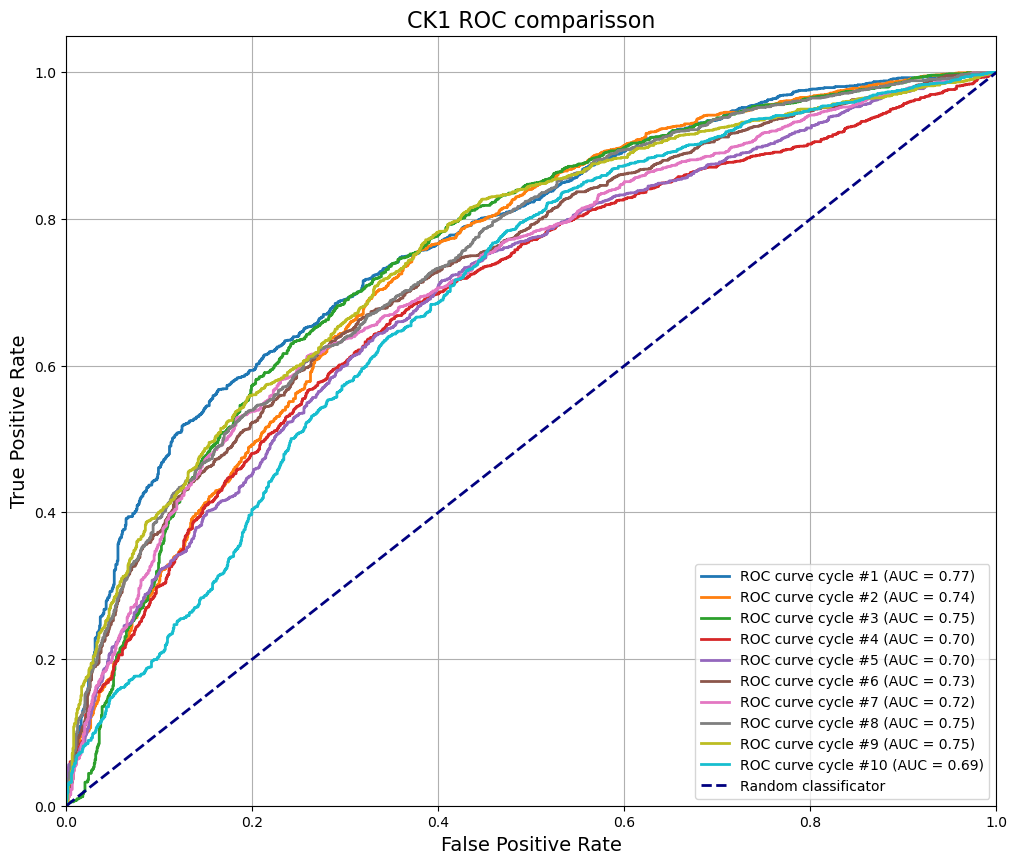

In [10]:


plt.figure(figsize=(12, 10))
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

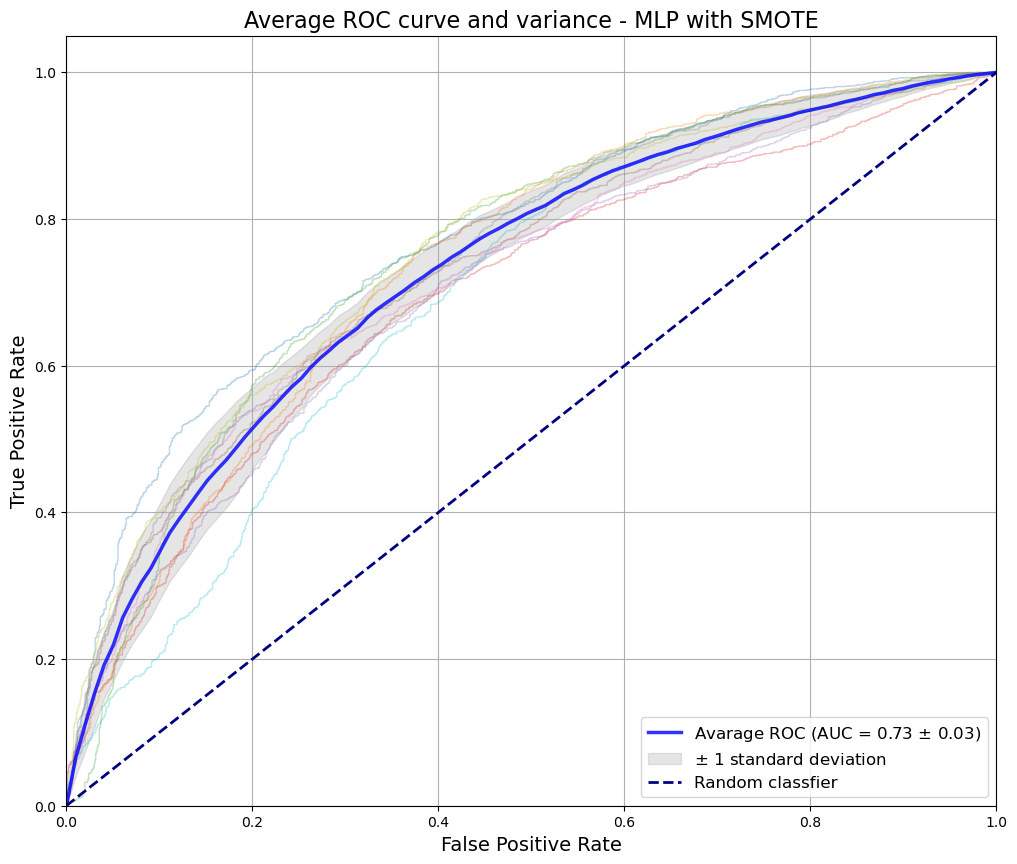

In [57]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 10))

for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP with SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('roc_herg.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

In [13]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))

In [14]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

# WITHOUT SMOTE

In [36]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'hERG_mlp_without_smote.csv')
df_existing_ws = pd.read_csv(csv_filename)
best_results_ws = df_existing_ws.iloc[:10]
best_results_ws = best_results_ws.iloc[:, 5:]
best_results_dicts_ws = []
for i,j in best_results_ws.iterrows():
    best_results_dicts_ws.append(dict(j))

In [37]:
df_existing_svc_ws = pd.read_csv("res/svc_without_smote_res_val_1.1.csv")
df_existing_svc_ws = df_existing_svc_ws.sort_values(by="mcc", ascending=False)
df_existing_svc_ws = df_existing_svc_ws.iloc[:2].drop("Unnamed: 0", axis=1)
df_existing_svc_ws = df_existing_svc_ws.iloc[:, :3]

best_results_svc_dicts_ws = []
for i,j in df_existing_svc_ws.iterrows():
    best_results_svc_dicts_ws.append(dict(j))

In [38]:
df_existing_knn_ws = pd.read_csv("res/knn_without_smote_res_val_1.1.csv")
df_existing_knn_ws = df_existing_knn_ws.sort_values(by="mcc", ascending=False)
df_existing_knn_ws = df_existing_knn_ws.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn_ws = df_existing_knn_ws.iloc[:, :6]
best_results_knn_dicts_ws = []
for i,j in df_existing_knn_ws.iterrows():
    best_results_knn_dicts_ws.append(dict(j))

In [39]:
pred_val_svc_ws = []
pred_test_svc_ws = []

pred_val_knn_ws = []
pred_test_knn_ws = []

pred_val_mlp_ws = []
pred_test_mlp_ws = []

for i in range(1,11):
    print("-----", i, "-----")
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)


    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc_ws = -1
    best_val_results_this_run_svc_ws = []
    best_test_results_this_run_svc_ws = []
    for j in best_results_svc_dicts_ws:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        if mcc > best_mcc_this_run_svc_ws:
            best_mcc_this_run_svc_ws = mcc
            best_val_results_this_run_svc_ws = svc.predict(x2)
            best_test_results_this_run_svc_ws = svc.predict(x3)
    pred_val_svc_ws.append(best_val_results_this_run_svc_ws)
    pred_test_svc_ws.append(best_test_results_this_run_svc_ws)

    best_mcc_this_run_ws = -1
    best_val_results_this_run_ws = []
    best_test_results_this_run_ws = []
    display("KNN")
    for j in best_results_knn_dicts_ws:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run_ws:
            best_mcc_this_run_ws = mcc
            best_val_results_this_run_ws = knn.predict(x2)
            best_test_results_this_run_ws = knn.predict(x3)
    pred_val_knn_ws.append(best_val_results_this_run_ws)
    pred_test_knn_ws.append(best_test_results_this_run_ws)

    best_mcc_this_run_mlp_ws = -1
    best_val_results_this_run_mlp_ws = []
    best_test_results_this_run_mlp_ws = []
    display("MLP")
    for j in best_results_dicts_ws:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run_mlp_ws:
            best_mcc_this_run_ws = mcc
            best_val_results_this_run_mlp_ws = mlp.predict(x2)
            best_test_results_this_run_mlp_ws = mlp.predict(x3)
    pred_val_mlp_ws.append(best_val_results_this_run_mlp_ws)
    pred_test_mlp_ws.append(best_test_results_this_run_mlp_ws)


----- 1 -----


'SVC'

'KNN'

'MLP'

----- 2 -----


...

'MLP'

----- 10 -----


'SVC'

'KNN'

'MLP'

In [40]:
all_y3 =[]
mcc_list_mlp_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list_mlp_ws.append(matthews_corrcoef(y_test, (np.array(pred_test_mlp_ws[i-1])>0.5)))

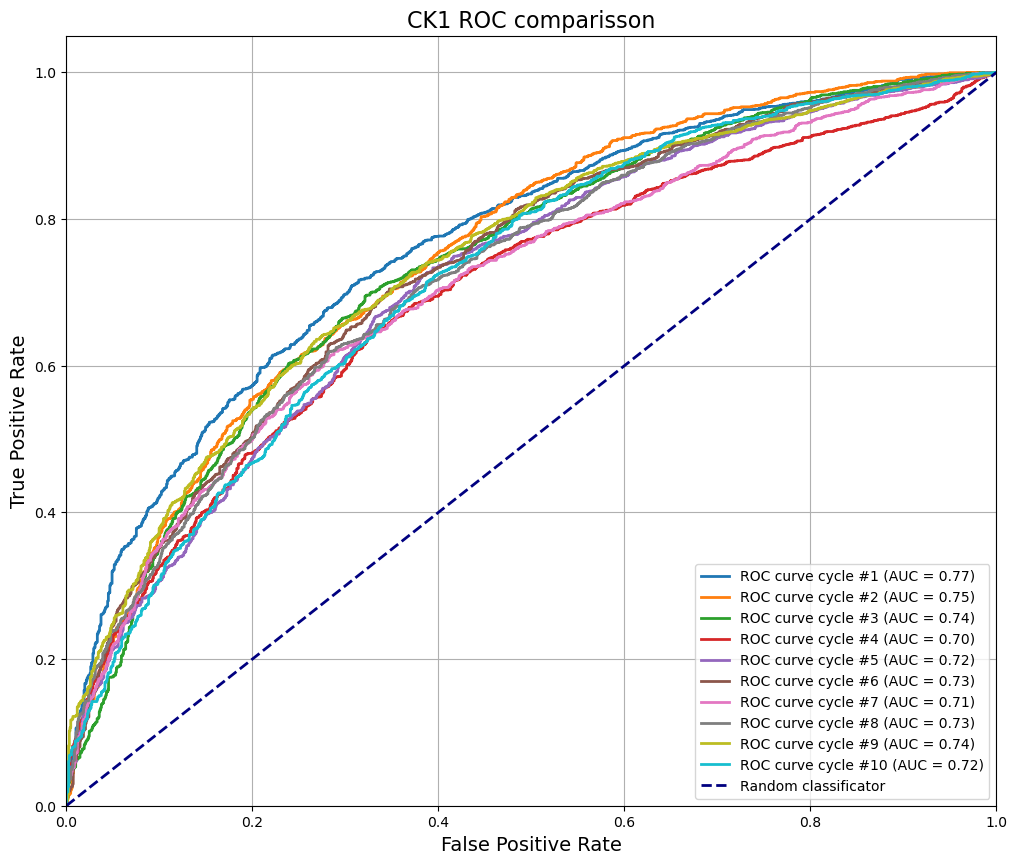

In [41]:
plt.figure(figsize=(12, 10))
for i in range(len(pred_test_mlp_ws)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp_ws[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

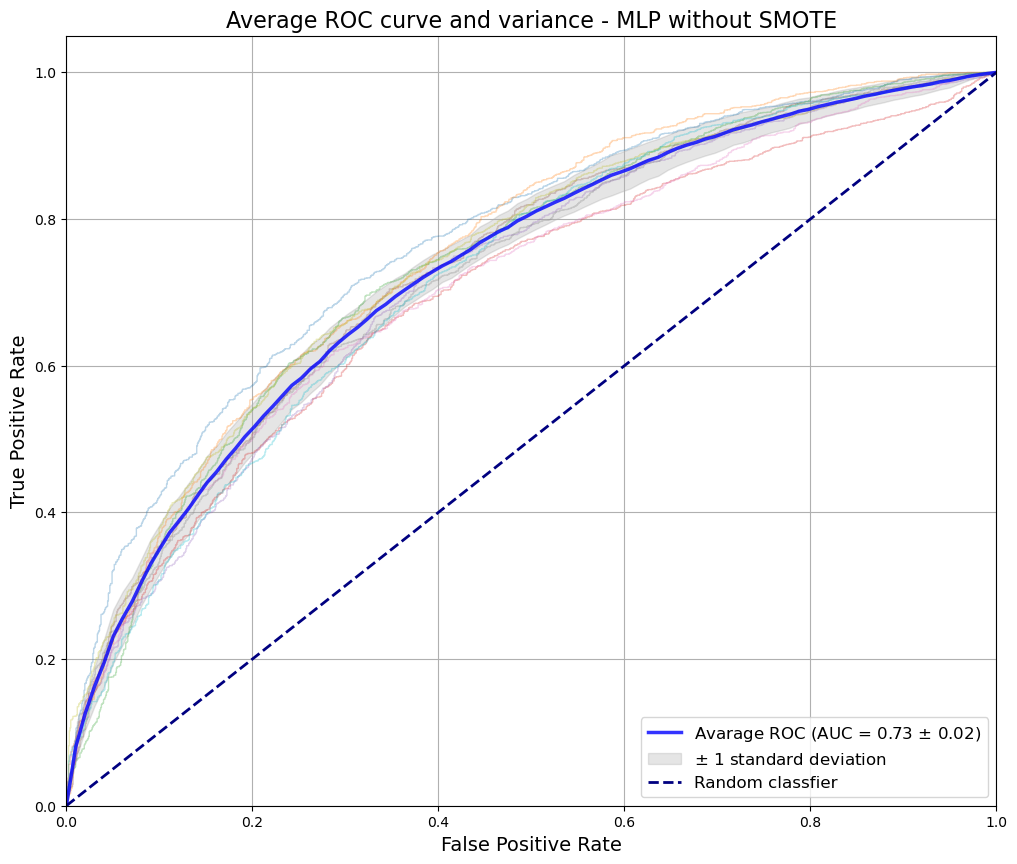

In [56]:
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(12, 10))

for i in range(len(pred_test_mlp_ws)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp_ws[i]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)


mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('roc_herg_ws.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
all_y3_knn_ws =[]
mcc_list_knn_ws = []
f1_list_knn_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn_ws.append(y_test)
    f1_list_knn_ws.append(matthews_corrcoef(y_test, (pred_test_mlp_ws[i-1]>0.5)))
    mcc_list_knn_ws.append(matthews_corrcoef(y_test, (pred_test_knn_ws[i-1]>0.5)))

In [44]:
all_y3_mlp_ws =[]
mcc_list_mlp_ws = []
f1_list_mlp_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp_ws.append(y_test)
    mcc_list_mlp_ws.append(matthews_corrcoef(y_test, (pred_test_mlp_ws[i-1]>0.5)))
    f1_list_mlp_ws.append(f1_score(y_test, (pred_test_mlp_ws[i-1]>0.5)))

In [45]:
all_y3_svc_ws =[]
mcc_list_svc_ws = []
f1_list_svc_ws = []
for i in range(1,11):
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc_ws.append(y_test)
    f1_list_svc_ws.append(f1_score(y_test, (pred_test_svc_ws[i-1]>0.5)))
    mcc_list_svc_ws.append(matthews_corrcoef(y_test, (pred_test_svc_ws[i-1]>0.5)))

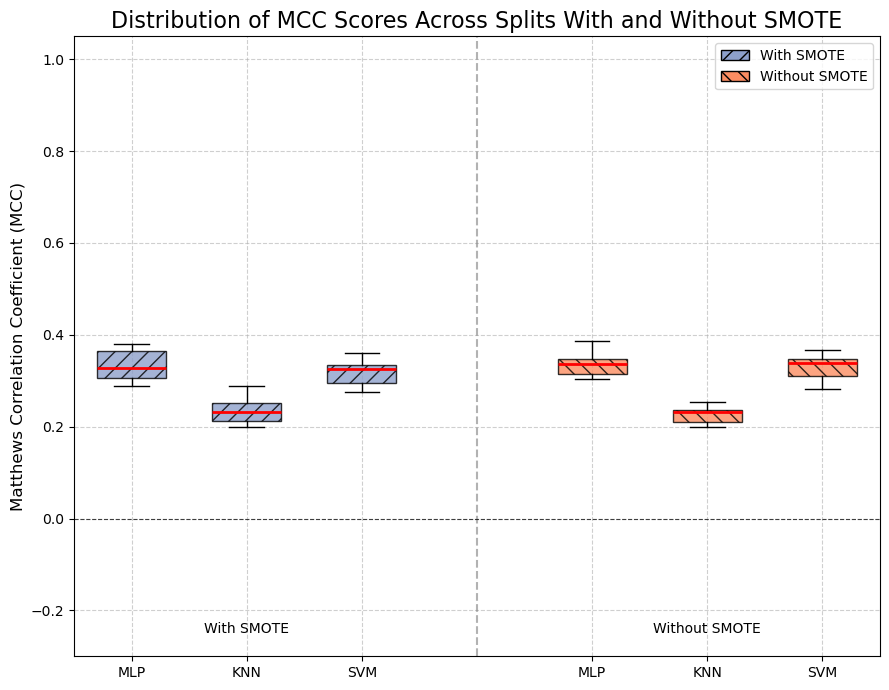

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_herg.png', dpi=300, bbox_inches='tight')
plt.show()


In [72]:
import pandas as pd
import numpy as np


def create_string(list_vals):
    return f"{np.mean(list_vals):.4f} ± {np.var(list_vals, ddof=1):.4f}"
# Příklad dat
data = {
    "Model": ["MLP", "MLP without SMOTE", "KNN", "KNN without SMOTE", "SVM", "SVM without SMOTE"],
    "F1": [create_string(f1_list_mlp), create_string(f1_list_mlp_ws), create_string(f1_list_knn), create_string(f1_list_knn_ws), create_string(f1_list_svc), create_string(f1_list_svc_ws)],
    "MCC": [create_string(mcc_list_mlp), create_string(mcc_list_mlp_ws), create_string(mcc_list_knn), create_string(mcc_list_knn_ws), create_string(mcc_list_svc), create_string(mcc_list_svc_ws)]
}

latex_code = df.to_latex(index=False, escape=False)
print(latex_code)

\begin{tabular}{lll}
\toprule
Model & F1 & MCC \\
\midrule
MLP & 0.7400 ± 0.0002 & 0.3341 ± 0.0011 \\
MLP without SMOTE & 0.7192 ± 0.0004 & 0.3347 ± 0.0007 \\
KNN & 0.3341 ± 0.0011 & 0.2337 ± 0.0008 \\
KNN without SMOTE & 0.3347 ± 0.0007 & 0.2253 ± 0.0004 \\
SVM & 0.7258 ± 0.0019 & 0.3172 ± 0.0008 \\
SVM without SMOTE & 0.7461 ± 0.0002 & 0.3289 ± 0.0008 \\
\bottomrule
\end{tabular}



In [58]:
np.median(mcc_list_mlp)

0.3279809085901753

In [61]:
print("With SMOTE")
print("MLP:")
print(mcc_list_mlp)
print("SVC:")
print(mcc_list_svc)
print("KNN:")
print(mcc_list_knn)
print("Without SMOTE:")
print("MLP:")
print(mcc_list_mlp_ws)
print("SVC:")
print(mcc_list_svc_ws)
print("KNN:")
print(mcc_list_knn_ws)

With SMOTE
MLP:
[0.36938780526481274, 0.3601101510752721, 0.3807337641943471, 0.28866143988556603, 0.30224919124005856, 0.32403405930259804, 0.30126524497399515, 0.3319277578777526, 0.36691882960111233, 0.31611515455535144]
SVC:
[0.36037501139962175, 0.27576328745295337, 0.3288276717875724, 0.28489795249714894, 0.3317658758179043, 0.3343552080411459, 0.2966309656161657, 0.3210627110658105, 0.3428618277301792, 0.29575787623444105]
KNN:
[0.28881266629941327, 0.24982533582770425, 0.25066788061765494, 0.20717731729707545, 0.19995115458302468, 0.2133939324930843, 0.22024813870814466, 0.25322663531697287, 0.24276032160051136, 0.21064778734979792]
Without SMOTE:
MLP:
[0.3863125722147296, 0.3462472989195834, 0.34780959229485986, 0.30481273334539216, 0.32581100890145587, 0.35055260471751687, 0.30411127310145286, 0.31347348140972464, 0.3477866732513266, 0.3202028254262333]
SVC:
[0.3504480275491407, 0.36742629281305156, 0.3396796127161722, 0.28788908172676325, 0.3191992185556172, 0.33751067919095

In [64]:
print("Median:")
print("With SMOTE")
print("MLP:")
print(np.median(mcc_list_mlp))
print("SVC:")
print(np.median(mcc_list_svc))
print("KNN:")
print(np.median(mcc_list_knn))
print("Without SMOTE:")
print("MLP:")
print(np.median(mcc_list_mlp_ws))
print("SVC:")
print(np.median(mcc_list_svc_ws))
print("KNN:")
print(np.median(mcc_list_knn_ws))

Median:
With SMOTE
MLP:
0.3279809085901753
SVC:
0.3249451914266914
KNN:
0.23150423015432803
Without SMOTE:
MLP:
0.33602915391051963
SVC:
0.3385951459535611
KNN:
0.2313286947678842


In [67]:
print("Q1:")
print("With SMOTE")
print("MLP:")
print(np.percentile(mcc_list_mlp, 25))
print("SVC:")
print(np.percentile(mcc_list_svc, 25))
print("KNN:")
print(np.percentile(mcc_list_knn, 25))
print("Without SMOTE:")
print("MLP:")
print(np.percentile(mcc_list_mlp_ws, 25))
print("SVC:")
print(np.percentile(mcc_list_svc_ws, 25))
print("KNN:")
print(np.percentile(mcc_list_knn_ws, 25))


Q1:
With SMOTE
MLP:
0.3057156820688818
SVC:
0.2959761485798722
KNN:
0.21133432363561952
Without SMOTE:
MLP:
0.3151558174138518
SVC:
0.311189644357145
KNN:
0.21024197277758583


In [69]:
print("Q3:")
print("With SMOTE")
print("MLP:")
print(np.percentile(mcc_list_mlp, 75))
print("SVC:")
print(np.percentile(mcc_list_svc, 75))
print("KNN:")
print(np.percentile(mcc_list_knn, 75))
print("Without SMOTE:")
print("MLP:")
print(np.percentile(mcc_list_mlp_ws, 75))
print("SVC:")
print(np.percentile(mcc_list_svc_ws, 75))
print("KNN:")
print(np.percentile(mcc_list_knn_ws, 75))

Q3:
With SMOTE
MLP:
0.36521665996965225
SVC:
0.3337078749853355
KNN:
0.25045724442016726
Without SMOTE:
MLP:
0.34780386253397655
SVC:
0.3484099769677014
KNN:
0.23570906566242436


In [71]:
y_test.sum()/y_test.count()

0.6188915375446961